# Stage 3: Collaborative Multi-Agent DDPG Dynamic Pricing Training

## Dynamic Electric Vehicle Charging Pricing — N-Network Collaborative DRL Training

**Base paper:** Lepolesa et al., "Dynamic Electric Vehicle Charging Pricing for Load Balancing in Power Distribution Networks based on Collaborative DDPG Agents", IEEE Transactions on Smart Grid, 2025.

**Reference Notebooks:** `DDPG_Approach_GPU.ipynb` & `DDPG_test_file_revised.ipynb` (from base paper repository)

---

### Agent Architecture & Roles:
For each of the $N=4$ distribution networks, two collaborative DDPG agents are trained:
1. **P1 Agent (Peak-Valley Shaving)**:
   - State: 24-hour normalized load profile of own network
   - Target / Reward: $r_{P1} = -\sum_{t=1}^{24} |a_{P1}(t) - \text{norm\_load}(t+1)|$
   - Action: 24-hour price markup $a_{P1} \in [0, 1]$ (higher during peak load to discourage charging, lower during valleys to encourage charging)

2. **P2 Agent (Inter-Network Load Balancing)**:
   - State: 24-hour normalized load profile of own network
   - Target / Reward: $r_{P2} = -\sum_{t=1}^{24} |a_{P2}(t) - \text{util\_diff\_dist}(t+1)|$
   - Action: 24-hour balancing markup $a_{P2} \in [0, 1]$ (higher when own network is overloaded relative to distance-weighted neighbors, encouraging shifting)

### Final Dynamic Price Output:
$$\text{EV\_Price}_i(t) = \text{Conv\_Price}(t) + 0.5 \times a_{P1, i}(t) + 0.5 \times a_{P2, i}(t)$$

### Checkpointing & Device Safety:
- Agents are automatically checkpointed via `torch.save` to `models/` so training progress is never lost
- Auto-detects CUDA / MPS / CPU devices

## 1. Imports and Reproducibility

All standard library and deep learning modules are explicitly imported.

In [1]:
import time
import os
import math
import random
from collections import deque
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Reproducibility seeds
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

warnings.filterwarnings('ignore')

# Device configuration
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using compute device: {dev}')

# Plotting settings
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Directories
OUTPUT_DIR = 'data'
MODEL_DIR = 'models'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

print('Libraries and environment initialized.')

Using compute device: cpu
Libraries and environment initialized.


## 2. Configuration & Hyperparameters

Hyperparameters are preserved from the base paper (`DDPG_Approach_GPU.ipynb` & `DDPG_test_file_revised.ipynb`):

| Hyperparameter | Value | Description |
|---|:---:|---|
| `state_dim` | 24 | 24-hour load state vector |
| `action_dim` | 24 | 24-hour pricing markup vector |
| `Actor Hidden Layers` | [64, 64] | Layer 1: Linear(24, 64) $\rightarrow$ Layer 2: Linear(64, 64) $\rightarrow$ Linear(64, 24) |
| `Critic Hidden Layers` | [64, 64] | Layer 1: Linear(48, 64) $\rightarrow$ Layer 2: Linear(64, 64) $\rightarrow$ Linear(64, 1) |
| `lr_actor` | 0.001 | Adam optimizer learning rate for Actor |
| `lr_critic` | 0.002 | Adam optimizer learning rate for Critic |
| `gamma` ($\gamma$) | 0.99 | Discount factor |
| `tau` ($\tau$) | 0.005 | Soft target network update rate |
| `batch_size` | 64 | Replay buffer batch sampling size |
| `NUM_EPISODES` | 300 | Training episodes for pipeline demonstration (increase on GPU) |

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Support configurable number of networks (3 or 4)
NUM_NETWORKS = 4
ALL_NETWORK_NAMES = ['residential', 'commercial', 'industrial', 'institutional']
NETWORK_NAMES = ALL_NETWORK_NAMES[:NUM_NETWORKS]

# Network capacities
NETWORK_MAX = {
    'residential':   1_166_666,
    'commercial':    1_000_000,
    'industrial':    1_500_000,
    'institutional':   800_000,
}

# DDPG Hyperparameters (matching base paper)
STATE_DIM = 24
ACTION_DIM = 24
LR_ACTOR = 0.001
LR_CRITIC = 0.002
GAMMA = 0.99
TAU = 0.005
BATCH_SIZE = 64
NUM_EPISODES = 300  # Set to 300 for fast local execution; 5000+ for GPU cluster
CHECKPOINT_FREQ = 50

# Test window parameters
TEST_START = 192 * 3  # Hour 576
TEST_WINDOW = 24

# Conventional pricing
CONV_PRICES = np.array([
    0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,   # 12AM to 6AM
    0.4, 0.7, 0.7,                         # 7AM to 9AM
    0.7, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7, 0.7,  # 10AM to 5PM
    0.7, 1.0, 1.0, 1.0, 0.7, 0.7           # 6PM to 11PM
])

TIME_LABELS = [
    '00:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',
    '12:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ','23:00'
]

print(f'Configured for {NUM_NETWORKS} networks: {NETWORK_NAMES}')
print(f'Training {NUM_NETWORKS * 2} DDPG agents across {NUM_EPISODES} episodes.')

Configured for 4 networks: ['residential', 'commercial', 'industrial', 'institutional']
Training 8 DDPG agents across 300 episodes.


## 3. Neural Network Architectures (Actor & Critic)

These classes are reproduced **verbatim** from `DDPG_test_file_revised.ipynb` (Cell 10).

In [3]:
# ============================================================
# ACTOR AND CRITIC NEURAL NETWORK MODULES (VERBATIM)
# Source: DDPG_test_file_revised.ipynb, Cell 10
# ============================================================

class Actor(nn.Module):
    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)
        self.tanh = nn.Tanh()
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))
        x = self.tanh(self.fc3(x))  # Output between -1 and 1
        return (x + 1) / 2          # Scale to range [0, 1]

class Critic(nn.Module):
    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(state_dim + action_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 1)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

print('Actor and Critic network definitions loaded.')

Actor and Critic network definitions loaded.


## 4. DDPG Agent Class with Checkpointing

Implements Experience Replay, Target Network soft updates ($\tau = 0.005$), and `save`/`load` functionality.

In [4]:
# ============================================================
# DDPG AGENT WRAPPER CLASS
# Source: DDPG_test_file_revised.ipynb, Cell 11 & 13
# ============================================================

class DDPGAgent:
    def __init__(self, state_dim=STATE_DIM, action_dim=ACTION_DIM,
                 lr_actor=LR_ACTOR, lr_critic=LR_CRITIC,
                 gamma=GAMMA, tau=TAU):
        self.actor = Actor(state_dim, action_dim).to(dev)
        self.critic = Critic(state_dim, action_dim).to(dev)
        self.target_actor = Actor(state_dim, action_dim).to(dev)
        self.target_critic = Critic(state_dim, action_dim).to(dev)
        
        self.target_actor.load_state_dict(self.actor.state_dict())
        self.target_critic.load_state_dict(self.critic.state_dict())
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
        self.gamma = gamma
        self.tau = tau
    
    def select_action(self, state):
        state_tensor = torch.FloatTensor(state).to(dev).unsqueeze(0)
        with torch.no_grad():
            action = self.actor(state_tensor).cpu().detach().numpy()
        return action[0]
    
    def update(self, replay_buffer, batch_size=BATCH_SIZE):
        if len(replay_buffer) < batch_size:
            return 0.0, 0.0
        
        batch = [replay_buffer[i] for i in np.random.choice(len(replay_buffer), batch_size, replace=False)]
        states, actions, rewards, next_states = zip(*batch)
        
        states = torch.FloatTensor(np.array(states)).to(dev)
        actions = torch.FloatTensor(np.array(actions)).to(dev)
        rewards = torch.FloatTensor(np.array(rewards)).to(dev).unsqueeze(1)
        next_states = torch.FloatTensor(np.array(next_states)).to(dev)
        
        # Target Critic update
        next_actions = self.target_actor(next_states)
        target_q = rewards + self.gamma * self.target_critic(next_states, next_actions).detach()
        
        # Critic loss
        q_values = self.critic(states, actions)
        critic_loss = F.mse_loss(q_values, target_q)
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        # Actor loss
        actor_loss = -self.critic(states, self.actor(states)).mean()
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()
        
        # Target networks soft update
        for param, target_param in zip(self.actor.parameters(), self.target_actor.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
        
        for param, target_param in zip(self.critic.parameters(), self.target_critic.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)
            
        return actor_loss.item(), critic_loss.item()

def save_ddpg_agent(agent, filepath):
    torch.save({
        'actor_state_dict': agent.actor.state_dict(),
        'critic_state_dict': agent.critic.state_dict(),
        'actor_optimizer_state_dict': agent.actor_optimizer.state_dict(),
        'critic_optimizer_state_dict': agent.critic_optimizer.state_dict()
    }, filepath)

def load_ddpg_agent(agent, filepath):
    checkpoint = torch.load(filepath, map_location=dev)
    agent.actor.load_state_dict(checkpoint['actor_state_dict'])
    agent.critic.load_state_dict(checkpoint['critic_state_dict'])
    agent.actor_optimizer.load_state_dict(checkpoint['actor_optimizer_state_dict'])
    agent.critic_optimizer.load_state_dict(checkpoint['critic_optimizer_state_dict'])

print('DDPG Agent class and checkpoint utilities defined.')

DDPG Agent class and checkpoint utilities defined.


## 5. Prepare Training Signals & Target Sequences

Load data from `data/n_network_net_load.csv` and prepare:
1. **P1 State & Target**: Normalized Net Load for Peak-Valley load flattening
2. **P2 State & Target**: Distance-Decay-Adjusted Renewable `util_diff` for Inter-Network balancing

In [5]:
# Load full 8736-hour net load dataset
df_full_net = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_net_load.csv'))
dist_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'network_distance_matrix.csv'), index_col=0)
dist_matrix = dist_df.values[:NUM_NETWORKS, :NUM_NETWORKS]

# Scaling and normalization
scaler = MinMaxScaler()
training_signals = {}

for name in NETWORK_NAMES:
    raw_net_load = df_full_net[f'{name}_net_load'].values.reshape(-1, 1)
    norm_load = scaler.fit_transform(raw_net_load).flatten()
    
    raw_net_diff = df_full_net[f'{name}_net_util_diff'].values.reshape(-1, 1)
    norm_diff = scaler.fit_transform(raw_net_diff).flatten()
    
    training_signals[name] = {
        'norm_load': norm_load,
        'norm_diff': norm_diff
    }

print(f'Training signals prepared for {NUM_NETWORKS} networks across {len(df_full_net)} hourly time steps.')

Training signals prepared for 4 networks across 8736 hourly time steps.


## 6. Training Function for Collaborative Multi-Agent DDPG

In [6]:
def train_single_ddpg_agent(agent_name, state_series, target_series, num_episodes=NUM_EPISODES,
                            sample_steps_per_ep=30, batch_size=BATCH_SIZE):
    """
    Train a DDPG agent on a 24-hour sequential environment with experience replay.
    
    Parameters:
    -----------
    agent_name : str
        Descriptive name (e.g. 'residential_p1').
    state_series : np.ndarray
        Series from which 24-hour state windows are sampled.
    target_series : np.ndarray
        Series from which reward targets are derived.
    num_episodes : int
        Number of training episodes.
    sample_steps_per_ep : int
        Number of 24-hour step transitions sampled per episode.
        
    Returns:
    --------
    agent : DDPGAgent
    history : dict (rewards, actor_losses, critic_losses)
    """
    agent = DDPGAgent()
    replay_buffer = deque(maxlen=20000)
    
    ep_rewards = []
    ep_actor_losses = []
    ep_critic_losses = []
    
    max_start_idx = len(state_series) - 48
    start_time = time.time()
    
    for episode in range(1, num_episodes + 1):
        total_reward = 0.0
        a_losses = []
        c_losses = []
        
        for _ in range(sample_steps_per_ep):
            idx = np.random.randint(0, max_start_idx)
            state = state_series[idx:idx+24]
            action = agent.select_action(state)
            
            # Target signal for reward computation
            target_val = target_series[idx+1:idx+25]
            reward = -np.mean(np.abs(action - target_val))
            next_state = state_series[idx+1:idx+25]
            
            replay_buffer.append((state, action, reward, next_state))
            total_reward += reward
            
            # Update networks
            if len(replay_buffer) >= batch_size:
                a_loss, c_loss = agent.update(replay_buffer, batch_size)
                a_losses.append(a_loss)
                c_losses.append(c_loss)
        
        ep_rewards.append(total_reward / sample_steps_per_ep)
        ep_actor_losses.append(np.mean(a_losses) if a_losses else 0.0)
        ep_critic_losses.append(np.mean(c_losses) if c_losses else 0.0)
        
        # Periodic checkpoint
        if episode % CHECKPOINT_FREQ == 0 or episode == num_episodes:
            ckpt_path = os.path.join(MODEL_DIR, f'ddpg_{agent_name}.pth')
            save_ddpg_agent(agent, ckpt_path)
    
    elapsed = time.time() - start_time
    print(f'✓ [{agent_name:<18}] Trained {num_episodes} eps ({elapsed:.1f}s) | Final Reward: {ep_rewards[-1]:.4f} | Saved: ddpg_{agent_name}.pth')
    
    history = {
        'reward': ep_rewards,
        'actor_loss': ep_actor_losses,
        'critic_loss': ep_critic_losses
    }
    return agent, history

## 7. Train All N×2 Collaborative DDPG Agents

Train 8 agents: P1 (Peak-Valley) and P2 (Balancing) for Residential, Commercial, Industrial, Institutional.

In [7]:
trained_agents = {}
training_histories = {}

print('='*70)
print(f'TRAINING {NUM_NETWORKS * 2} COLLABORATIVE DDPG PRICING AGENTS')
print('='*70)

for name in NETWORK_NAMES:
    norm_load = training_signals[name]['norm_load']
    norm_diff = training_signals[name]['norm_diff']
    
    # Train P1 Agent (Peak-Valley load flattening)
    p1_agent, p1_hist = train_single_ddpg_agent(
        agent_name=f'{name}_p1',
        state_series=norm_load,
        target_series=norm_load,
        num_episodes=NUM_EPISODES
    )
    trained_agents[f'{name}_p1'] = p1_agent
    training_histories[f'{name}_p1'] = p1_hist
    
    # Train P2 Agent (Inter-network balancing)
    p2_agent, p2_hist = train_single_ddpg_agent(
        agent_name=f'{name}_p2',
        state_series=norm_load,
        target_series=norm_diff,
        num_episodes=NUM_EPISODES
    )
    trained_agents[f'{name}_p2'] = p2_agent
    training_histories[f'{name}_p2'] = p2_hist

print('='*70)
print('All collaborative DDPG pricing agents trained and checkpointed.')

TRAINING 8 COLLABORATIVE DDPG PRICING AGENTS


✓ [residential_p1    ] Trained 300 eps (8.7s) | Final Reward: -0.1315 | Saved: ddpg_residential_p1.pth


✓ [residential_p2    ] Trained 300 eps (8.4s) | Final Reward: -0.1062 | Saved: ddpg_residential_p2.pth


✓ [commercial_p1     ] Trained 300 eps (8.5s) | Final Reward: -0.1553 | Saved: ddpg_commercial_p1.pth


✓ [commercial_p2     ] Trained 300 eps (8.6s) | Final Reward: -0.1219 | Saved: ddpg_commercial_p2.pth


✓ [industrial_p1     ] Trained 300 eps (8.5s) | Final Reward: -0.1234 | Saved: ddpg_industrial_p1.pth


✓ [industrial_p2     ] Trained 300 eps (8.5s) | Final Reward: -0.0980 | Saved: ddpg_industrial_p2.pth


✓ [institutional_p1  ] Trained 300 eps (8.4s) | Final Reward: -0.1273 | Saved: ddpg_institutional_p1.pth


✓ [institutional_p2  ] Trained 300 eps (8.8s) | Final Reward: -0.1087 | Saved: ddpg_institutional_p2.pth
All collaborative DDPG pricing agents trained and checkpointed.


## 8. Test Window Evaluation & Dynamic Price Generation

On the 24-hour test window (hours 576 to 599):
1. Each network's normalized state is passed to its respective P1 and P2 agents.
2. Actions $a_{P1}(t)$ and $a_{P2}(t)$ are combined with the conventional tariff:
$$\text{EV\_Price}_i(t) = \text{Conv\_Price}(t) + 0.5 \times a_{P1, i}(t) + 0.5 \times a_{P2, i}(t)$$

In [8]:
# Load test window data
df_test = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_24h_test.csv'))
hours = np.arange(24)

actions_p1 = {}
actions_p2 = {}
ev_dynamic_prices = {}

for name in NETWORK_NAMES:
    # Extract test window normalized state
    test_net_l = df_test[f'{name}_net_load'].values.reshape(-1, 1)
    test_state = scaler.fit_transform(test_net_l).flatten()
    
    # Infer actions
    act_p1 = trained_agents[f'{name}_p1'].select_action(test_state)
    act_p2 = trained_agents[f'{name}_p2'].select_action(test_state)
    
    actions_p1[name] = act_p1
    actions_p2[name] = act_p2
    
    # Compute dynamic price
    ev_price = CONV_PRICES + 0.5 * act_p1 + 0.5 * act_p2
    ev_dynamic_prices[name] = ev_price

print('Dynamic EV Charging Prices on 24-Hour Test Window:')
print(f'{"Network":<16} {"Min Price":>12} {"Max Price":>12} {"Mean Price":>12} {"Conv Mean":>12}')
print('-' * 70)
for name in NETWORK_NAMES:
    p = ev_dynamic_prices[name]
    print(f'{name:<16} {p.min():>12.3f} {p.max():>12.3f} {p.mean():>12.3f} {CONV_PRICES.mean():>12.3f}')

Dynamic EV Charging Prices on 24-Hour Test Window:
Network             Min Price    Max Price   Mean Price    Conv Mean
----------------------------------------------------------------------
residential             0.400        1.880        0.910        0.700
commercial              0.423        1.489        0.938        0.700
industrial              0.400        1.930        1.005        0.700
institutional           0.401        1.916        0.925        0.700


## 9. Visualizations

### Plot 1: DDPG Training Loss and Reward Curves

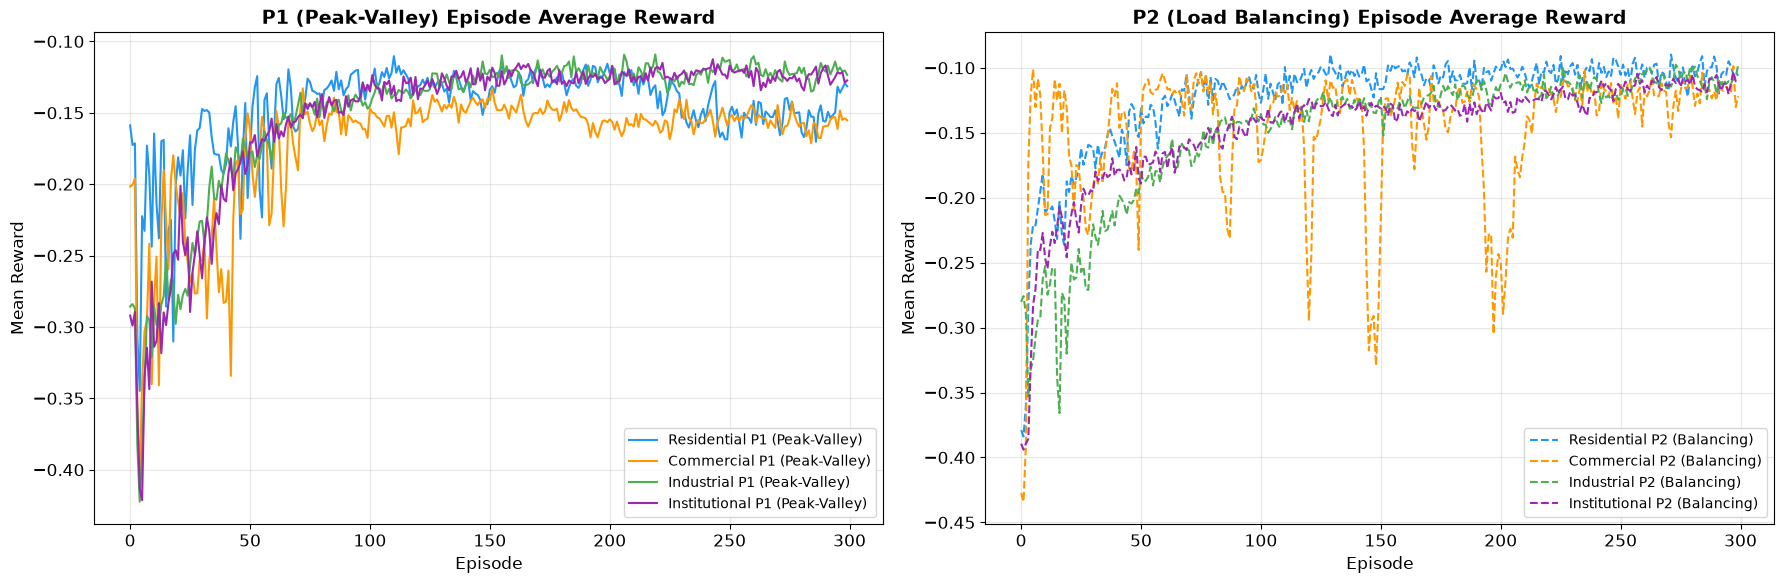

In [9]:
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# P1 Agent Rewards
for idx, name in enumerate(NETWORK_NAMES):
    hist = training_histories[f'{name}_p1']
    ax1.plot(hist['reward'], color=colors[idx], label=f'{name.capitalize()} P1 (Peak-Valley)')

ax1.set_title('P1 (Peak-Valley) Episode Average Reward', fontsize=14, fontweight='bold')
ax1.set_xlabel('Episode', fontsize=12)
ax1.set_ylabel('Mean Reward', fontsize=12)
ax1.legend(fontsize=10)

# P2 Agent Rewards
for idx, name in enumerate(NETWORK_NAMES):
    hist = training_histories[f'{name}_p2']
    ax2.plot(hist['reward'], color=colors[idx], linestyle='--', label=f'{name.capitalize()} P2 (Balancing)')

ax2.set_title('P2 (Load Balancing) Episode Average Reward', fontsize=14, fontweight='bold')
ax2.set_xlabel('Episode', fontsize=12)
ax2.set_ylabel('Mean Reward', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Plot 2: Action Decomposition and Resulting Dynamic Price per Network

Shows the conventional tariff, P1 peak-valley markup, P2 balancing markup, and final price.

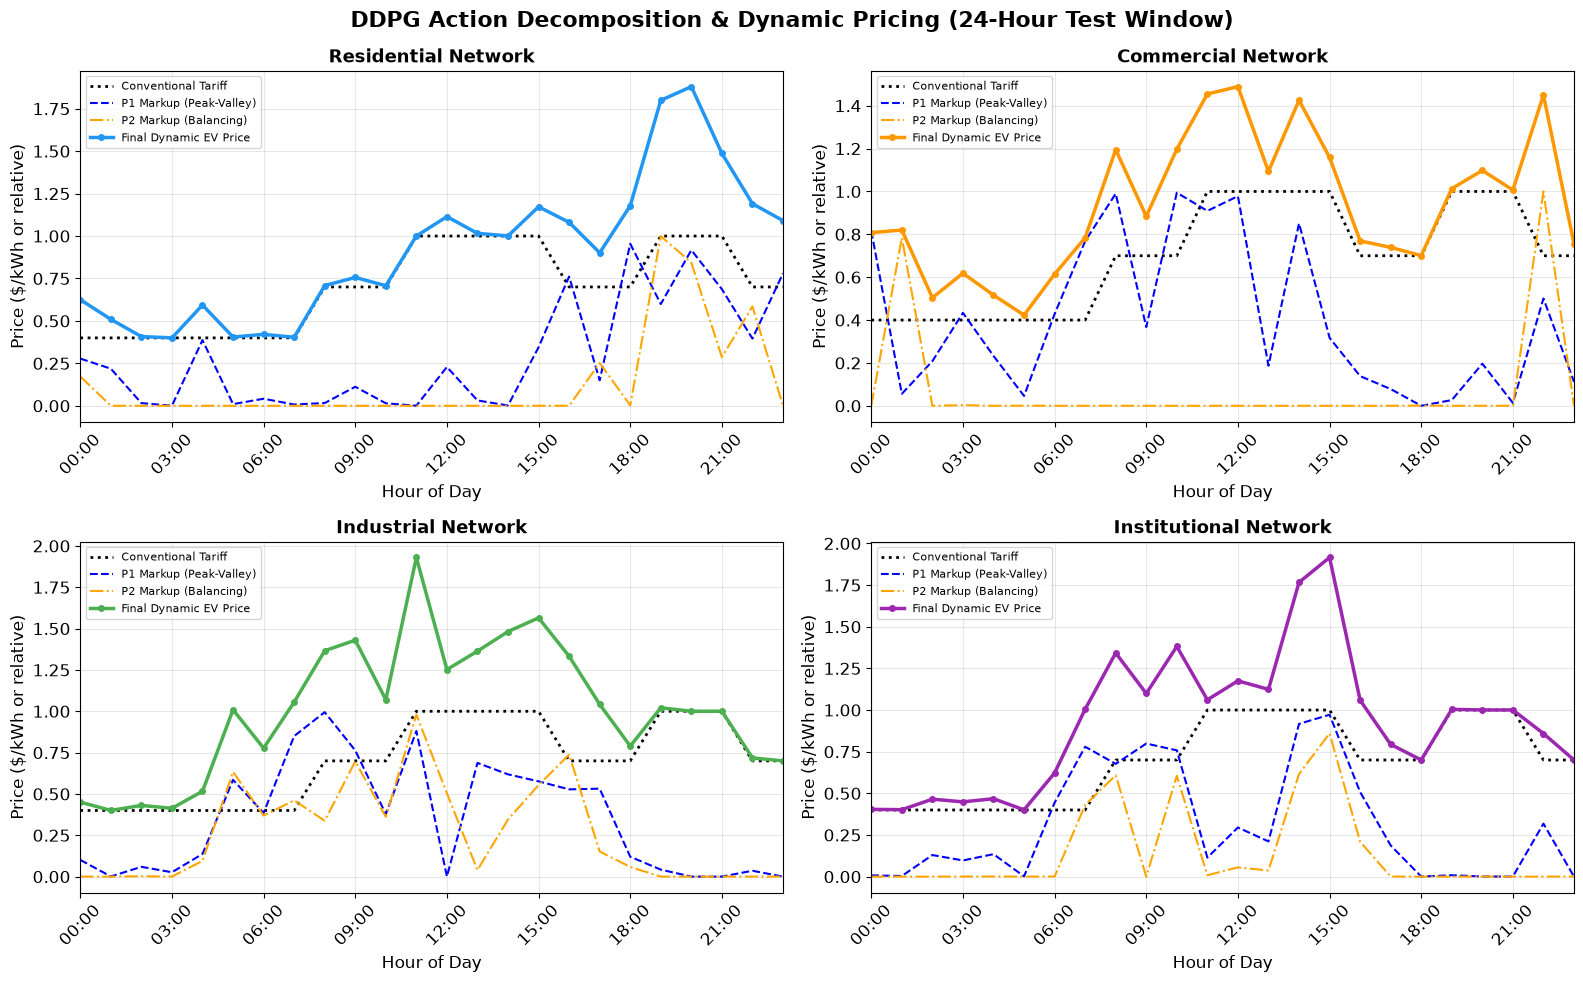

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('DDPG Action Decomposition & Dynamic Pricing (24-Hour Test Window)', fontsize=16, fontweight='bold')

for idx, (name, color) in enumerate(zip(NETWORK_NAMES, colors)):
    ax = axes[idx // 2, idx % 2]
    
    ax.plot(hours, CONV_PRICES, color='black', linestyle=':', linewidth=2, label='Conventional Tariff')
    ax.plot(hours, actions_p1[name], color='blue', linestyle='--', linewidth=1.5, label='P1 Markup (Peak-Valley)')
    ax.plot(hours, actions_p2[name], color='orange', linestyle='-.', linewidth=1.5, label='P2 Markup (Balancing)')
    ax.plot(hours, ev_dynamic_prices[name], color=color, linewidth=2.5, marker='o', markersize=4, label='Final Dynamic EV Price')
    
    ax.set_title(f'{name.capitalize()} Network', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Price ($/kWh or relative)')
    ax.set_xticks(hours[::3])
    ax.set_xticklabels([f'{h:02d}:00' for h in hours[::3]], rotation=45)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0, 23)

plt.tight_layout()
plt.show()

### Plot 3: Dual Y-Axis Total Load vs. Dynamic Prices (Base Paper Style)

Reproduces the presentation style of `DDPG_test_file_revised.ipynb` (Cell 21), showing how dynamic prices mirror load variations.

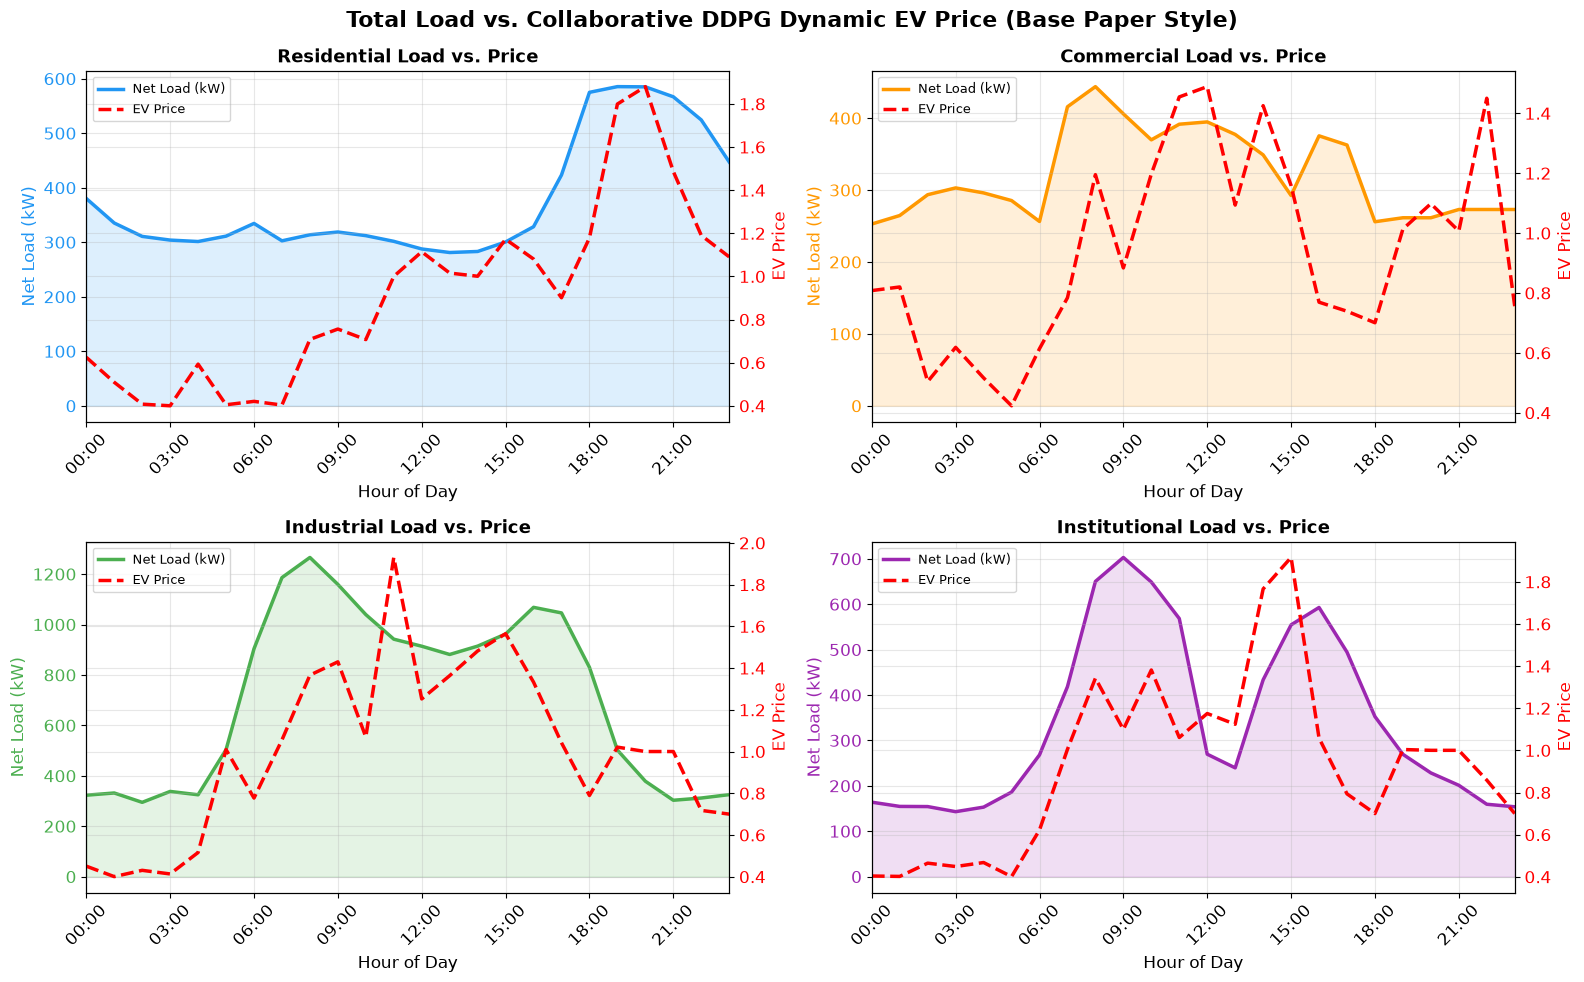

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Total Load vs. Collaborative DDPG Dynamic EV Price (Base Paper Style)', fontsize=16, fontweight='bold')

for idx, (name, color) in enumerate(zip(NETWORK_NAMES, colors)):
    ax1 = axes[idx // 2, idx % 2]
    
    # Load axis
    load_kw = df_test[f'{name}_net_load'].values / 1000
    line1, = ax1.plot(hours, load_kw, color=color, linewidth=2.5, label='Net Load (kW)')
    ax1.fill_between(hours, load_kw, color=color, alpha=0.15)
    ax1.set_xlabel('Hour of Day')
    ax1.set_ylabel('Net Load (kW)', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(hours[::3])
    ax1.set_xticklabels([f'{h:02d}:00' for h in hours[::3]], rotation=45)
    
    # Price axis
    ax2 = ax1.twinx()
    line2, = ax2.plot(hours, ev_dynamic_prices[name], color='red', linestyle='--', linewidth=2.5, label='EV Dynamic Price')
    ax2.set_ylabel('EV Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    
    ax1.set_title(f'{name.capitalize()} Load vs. Price', fontsize=13, fontweight='bold')
    ax1.legend([line1, line2], ['Net Load (kW)', 'EV Price'], loc='upper left', fontsize=9)
    ax1.set_xlim(0, 23)

plt.tight_layout()
plt.show()

## 10. Export Datasets and Models

In [12]:
# 1. Export ddpg_dynamic_prices_test_24h.csv
df_prices_export = pd.DataFrame({'Hour': hours, 'Time': df_test['Time'], 'Conv_price': CONV_PRICES})

for name in NETWORK_NAMES:
    df_prices_export[f'{name}_action_p1'] = actions_p1[name]
    df_prices_export[f'{name}_action_p2'] = actions_p2[name]
    df_prices_export[f'{name}_ev_dynamic_price'] = ev_dynamic_prices[name]

prices_csv_path = os.path.join(OUTPUT_DIR, 'ddpg_dynamic_prices_test_24h.csv')
df_prices_export.to_csv(prices_csv_path, index=False)
print(f'1. Written: {prices_csv_path} ({len(df_prices_export)} rows x {len(df_prices_export.columns)} cols)')

# 2. Export ddpg_training_stats.csv
df_stats = pd.DataFrame({'Episode': range(1, NUM_EPISODES + 1)})
for agent_key, hist in training_histories.items():
    df_stats[f'{agent_key}_reward'] = hist['reward']
    df_stats[f'{agent_key}_actor_loss'] = hist['actor_loss']
    df_stats[f'{agent_key}_critic_loss'] = hist['critic_loss']

stats_csv_path = os.path.join(OUTPUT_DIR, 'ddpg_training_stats.csv')
df_stats.to_csv(stats_csv_path, index=False)
print(f'2. Written: {stats_csv_path} ({len(df_stats)} rows x {len(df_stats.columns)} cols)')

# 3. Update n_network_24h_test.csv with price columns
test_csv_path = os.path.join(OUTPUT_DIR, 'n_network_24h_test.csv')
df_test_full = pd.read_csv(test_csv_path)

for name in NETWORK_NAMES:
    df_test_full[f'{name}_action_p1'] = actions_p1[name]
    df_test_full[f'{name}_action_p2'] = actions_p2[name]
    df_test_full[f'{name}_ev_dynamic_price'] = ev_dynamic_prices[name]

df_test_full.to_csv(test_csv_path, index=False)
print(f'3. Updated: {test_csv_path} ({len(df_test_full)} rows x {len(df_test_full.columns)} cols)')

1. Written: data/ddpg_dynamic_prices_test_24h.csv (24 rows x 15 cols)
2. Written: data/ddpg_training_stats.csv (300 rows x 25 cols)
3. Updated: data/n_network_24h_test.csv (24 rows x 74 cols)


## 11. Verification of Models and Datasets

In [13]:
print('='*60)
print('STAGE 3 EXPORT & CHECKPOINT VERIFICATION')
print('='*60)

all_ok = True

# Check model checkpoints
for name in NETWORK_NAMES:
    for p in ['p1', 'p2']:
        m_path = os.path.join(MODEL_DIR, f'ddpg_{name}_{p}.pth')
        if os.path.exists(m_path):
            print(f'  [OK] Checkpoint exists: {m_path}')
        else:
            print(f'  [MISSING] Checkpoint: {m_path}')
            all_ok = False

print()
# Check CSV files
csv_checks = [
    ('ddpg_dynamic_prices_test_24h.csv', 24, 3 + 3 * NUM_NETWORKS),
    ('ddpg_training_stats.csv', NUM_EPISODES, 1 + 6 * NUM_NETWORKS),
    ('n_network_24h_test.csv', 24, 62 + 3 * NUM_NETWORKS),
]

for fname, exp_r, exp_c in csv_checks:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        df_c = pd.read_csv(fpath)
        r_ok = len(df_c) == exp_r
        c_ok = len(df_c.columns) == exp_c
        status = 'OK' if (r_ok and c_ok) else 'MISMATCH'
        if not (r_ok and c_ok):
            all_ok = False
        print(f'  [{status}] {fname}: {len(df_c)} rows x {len(df_c.columns)} cols')
    else:
        print(f'  [MISSING] {fname}')
        all_ok = False

print()
if all_ok:
    print('All Stage 3 DDPG agents and datasets verified successfully.')
else:
    print('WARNING: File or checkpoint verification issues detected.')

STAGE 3 EXPORT & CHECKPOINT VERIFICATION
  [OK] Checkpoint exists: models/ddpg_residential_p1.pth
  [OK] Checkpoint exists: models/ddpg_residential_p2.pth
  [OK] Checkpoint exists: models/ddpg_commercial_p1.pth
  [OK] Checkpoint exists: models/ddpg_commercial_p2.pth
  [OK] Checkpoint exists: models/ddpg_industrial_p1.pth
  [OK] Checkpoint exists: models/ddpg_industrial_p2.pth
  [OK] Checkpoint exists: models/ddpg_institutional_p1.pth
  [OK] Checkpoint exists: models/ddpg_institutional_p2.pth

  [OK] ddpg_dynamic_prices_test_24h.csv: 24 rows x 15 cols
  [OK] ddpg_training_stats.csv: 300 rows x 25 cols
  [OK] n_network_24h_test.csv: 24 rows x 74 cols

All Stage 3 DDPG agents and datasets verified successfully.


## 12. Summary — What to Report in the Paper

In [14]:
print('='*70)
print('STAGE 3 SUMMARY -- WHAT TO REPORT IN THE PAPER')
print('='*70)
print()
print('1. COLLABORATIVE DDPG ARCHITECTURE:')
net_str = ', '.join(NETWORK_NAMES)
print(f'   - Number of Networks: {NUM_NETWORKS} ({net_str})')
print(f'   - Total DDPG Agents: {NUM_NETWORKS * 2} (P1 Peak-Valley + P2 Balancing per network)')
print('   - Actor Architecture: 24 -> 64 -> 64 -> 24 (Tanh -> [0, 1])')
print('   - Critic Architecture: 48 -> 64 -> 64 -> 1')
print('   - Learning Rates: lr_actor=0.001, lr_critic=0.002, gamma=0.99, tau=0.005')
print()
print('2. DYNAMIC PRICING FORMULA:')
print('   EV_Price_i(t) = Conv_Price(t) + 0.5 * a_P1,i(t) + 0.5 * a_P2,i(t)')
print()
print('3. TEST WINDOW PRICING SUMMARY:')
for name in NETWORK_NAMES:
    p = ev_dynamic_prices[name]
    print(f'   - {name.capitalize():<14}: Min={p.min():.3f}, Max={p.max():.3f}, Mean={p.mean():.3f} (Markup over conv: +{p.mean()-CONV_PRICES.mean():.3f})')
print()
print('4. SAVED MODEL CHECKPOINTS:')
for name in NETWORK_NAMES:
    print(f'   - models/ddpg_{name}_p1.pth, models/ddpg_{name}_p2.pth')

STAGE 3 SUMMARY -- WHAT TO REPORT IN THE PAPER

1. COLLABORATIVE DDPG ARCHITECTURE:
   - Number of Networks: 4 (residential, commercial, industrial, institutional)
   - Total DDPG Agents: 8 (P1 Peak-Valley + P2 Balancing per network)
   - Actor Architecture: 24 -> 64 -> 64 -> 24 (Tanh -> [0, 1])
   - Critic Architecture: 48 -> 64 -> 64 -> 1
   - Learning Rates: lr_actor=0.001, lr_critic=0.002, gamma=0.99, tau=0.005

2. DYNAMIC PRICING FORMULA:
   EV_Price_i(t) = Conv_Price(t) + 0.5 * a_P1,i(t) + 0.5 * a_P2,i(t)

3. TEST WINDOW PRICING SUMMARY:
   - Residential   : Min=0.400, Max=1.880, Mean=0.910 (Markup over conv: +0.210)
   - Commercial    : Min=0.423, Max=1.489, Mean=0.938 (Markup over conv: +0.238)
   - Industrial    : Min=0.400, Max=1.930, Mean=1.005 (Markup over conv: +0.305)
   - Institutional : Min=0.401, Max=1.916, Mean=0.925 (Markup over conv: +0.225)

4. SAVED MODEL CHECKPOINTS:
   - models/ddpg_residential_p1.pth, models/ddpg_residential_p2.pth
   - models/ddpg_commercial_p